# SHAP Analysis — Risk Classification

**Project:** Diabetes Risk Segmentation & Decision Support System  
**Framework:** CRISP-DM — Evaluation Phase  
**Model:** XGBoost (best performing classifier)  

This notebook covers:
1. Data preparation via `preprocessing.py`
2. SHAP TreeExplainer on XGBoost predictions
3. Global summary bar plot — top drivers overall
4. Beeswarm plot — direction and magnitude of feature impact
5. Per-class SHAP bar plots — drivers per diabetes stage
6. Insights & documentation

## 1. Imports & Setup

In [17]:
import sys
import os
import subprocess
import warnings
warnings.filterwarnings('ignore')

subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "xgboost", "joblib", "--quiet"])

project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..')) if '__file__' in globals() else os.path.abspath('..')
src_path = os.path.join(project_root, 'src')
if project_root not in sys.path:
    sys.path.insert(1, project_root)
if src_path not in sys.path:
    sys.path.insert(2, src_path)
print(f"Project root added: {project_root}")
print(f"SRC path added: {src_path}")

from data_preprocessing import run_pipeline  # Correct module name

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

np.random.seed(42)
print(f"SHAP {shap.__version__} ready.")


Project root added: c:\Users\Jacks\Downloads\MLG382-Group-1-Web-App-and-ML-Model--main(1)\MLG382-Group-1-Web-App-and-ML-Model--main
SRC path added: c:\Users\Jacks\Downloads\MLG382-Group-1-Web-App-and-ML-Model--main(1)\MLG382-Group-1-Web-App-and-ML-Model--main\src
SHAP 0.51.0 ready.


## 2. Data Preparation & Model Loading

In [18]:

# Load raw CSV with correct relative path (from notebooks/)
csv_path = '../data/raw/Diabetes_and_LifeStyle_Dataset_.csv'
df = pd.read_csv(csv_path)
print(f"Loaded CSV shape: {df.shape}")
print(f"CSV path exists: {os.path.exists(csv_path)}")

# Run pipeline (assumes it returns dict with keys below)
result = run_pipeline(df)

X_test_proc = result['X_test']
y_test = result['y_test']
label_encoder = result['label_encoder']
feature_names = list(result['feature_names'])  # e.g., ['num__hba1c', 'cat__gender_Male']
classes = list(label_encoder.classes_)
n_classes = len(classes)

# Readable display labels — strip prefixes
disp_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

# Load best model with correct relative path (note: code says xgb_model but loads RF - fix filename)
model_path = '../artifacts/xgboost_best_model.pkl'  
xgb_model = joblib.load(model_path)
print(f"Model loaded from: {model_path}")
print(f"Model path exists: {os.path.exists(model_path)}")

print(f'Test set shape : {X_test_proc.shape}')
print(f'Classes        : {classes}')
print(f'n_classes      : {n_classes}')
print(f"Feature names sample: {feature_names[:5]}")
print(f"Display names sample: {disp_names[:5]}")

2026-04-17 09:07:53,761 - INFO - After duplicate removal: (97297, 31)


Loaded CSV shape: (97297, 31)
CSV path exists: True


2026-04-17 09:07:53,898 - INFO - Feature engineering completed
2026-04-17 09:07:54,565 - INFO - Train shape: (37417, 58)
2026-04-17 09:07:54,566 - INFO - Test shape: (19460, 58)


Model loaded from: ../artifacts/xgboost_best_model.pkl
Model path exists: True
Test set shape : (19460, 58)
Classes        : ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']
n_classes      : 5
Feature names sample: ['num__age', 'num__alcohol_consumption_per_week', 'num__physical_activity_minutes_per_week', 'num__diet_score', 'num__sleep_hours_per_day']
Display names sample: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day']


## 3. SHAP Computation

We use `TreeExplainer` — the exact, efficient explainer for tree-based models.  
500 test-set rows are sampled; sufficient for stable global importance estimates across 58 features.  

`shap_values` shape: `(samples, features, classes)`.

In [19]:
rng        = np.random.RandomState(42)
sample_idx = rng.choice(X_test_proc.shape[0], size=500, replace=False)
X_shap     = X_test_proc[sample_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap) 

print(f'SHAP values shape: {shap_values.shape}')
print(f'  axis 0 = samples  ({shap_values.shape[0]})')
print(f'  axis 1 = features ({shap_values.shape[1]})')
print(f'  axis 2 = classes  ({shap_values.shape[2]}) → {classes}')

SHAP values shape: (500, 58, 5)
  axis 0 = samples  (500)
  axis 1 = features (58)
  axis 2 = classes  (5) → ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']


## 4. Global Summary — Top Drivers Overall

Mean absolute SHAP value averaged across **all five classes**, giving the overall importance of each feature for the classification task.

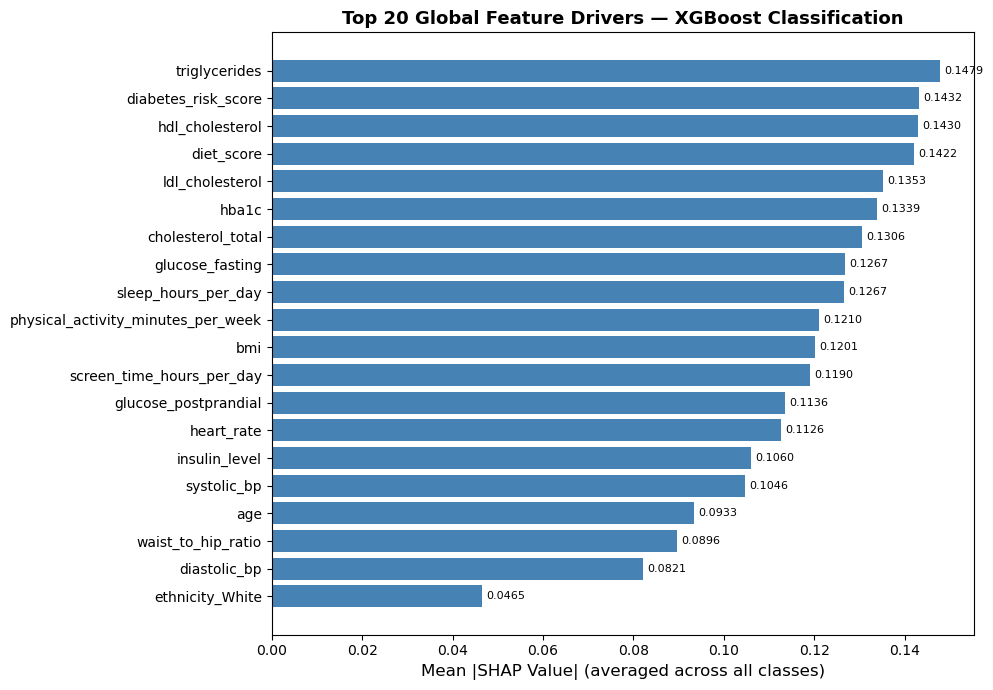


Top 10 global drivers:
                           Feature  Mean |SHAP|
                     triglycerides     0.147866
               diabetes_risk_score     0.143159
                   hdl_cholesterol     0.142970
                        diet_score     0.142172
                   ldl_cholesterol     0.135304
                             hba1c     0.133851
                 cholesterol_total     0.130587
                   glucose_fasting     0.126737
               sleep_hours_per_day     0.126676
physical_activity_minutes_per_week     0.121017


In [20]:
# Mean |SHAP| across all classes => global importance per feature
global_imp = np.abs(shap_values).mean(axis=(0, 2))

fi_df = pd.DataFrame({'Feature': disp_names, 'Mean |SHAP|': global_imp})
fi_df = fi_df.sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
top20 = fi_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['Feature'][::-1], top20['Mean |SHAP|'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP Value| (averaged across all classes)', fontsize=12)
ax.set_title('Top 20 Global Feature Drivers — XGBoost Classification',
             fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('shap_cls_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 global drivers:')
print(fi_df.head(10).to_string(index=False))

## 5. Beeswarm Plot — Direction & Magnitude

- **Red** = high feature value pushes prediction in this direction  
- **Blue** = low feature value  
- x-axis position = SHAP value (positive → pushes toward higher-risk class; negative → away)  

We aggregate SHAP across all classes (mean |SHAP|) for a single consolidated view.

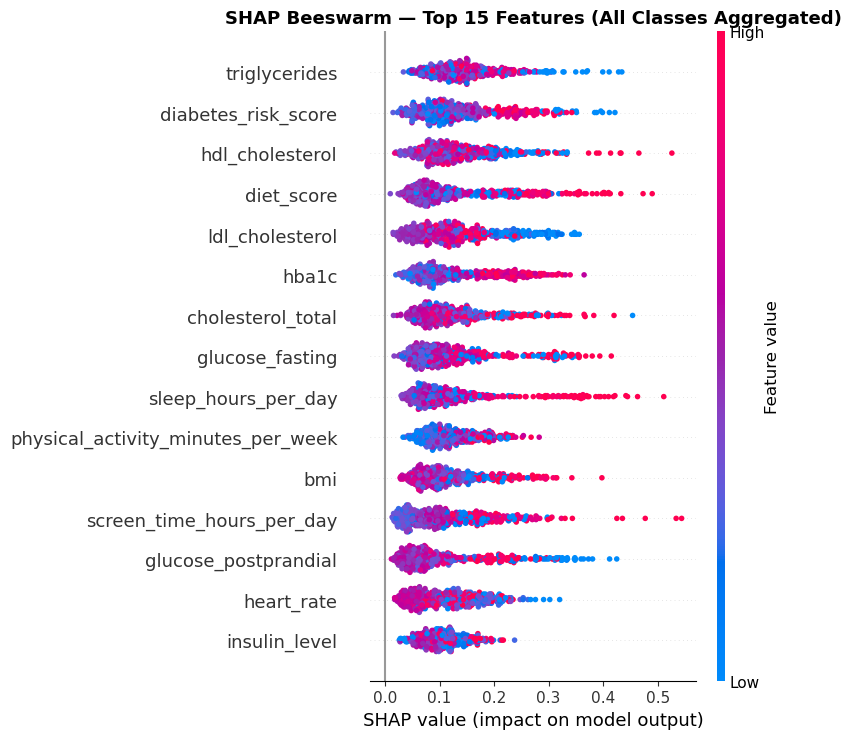

In [21]:
# Aggregate: mean |SHAP| across classes per observation => (500, 58)
shap_agg = np.abs(shap_values).mean(axis=2)

# Top 15 features
top15_idx   = np.argsort(global_imp)[-15:][::-1]
top15_names = [disp_names[i] for i in top15_idx]
top15_shap  = shap_agg[:, top15_idx]
top15_data  = X_shap[:, top15_idx]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    top15_shap, top15_data,
    feature_names=top15_names,
    show=False, plot_type='dot', max_display=15
)
plt.title('SHAP Beeswarm — Top 15 Features (All Classes Aggregated)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_cls_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-Class SHAP Bar Plots — Drivers per Diabetes Stage

Each subplot shows the top 10 features driving that specific diabetes stage.  
Different risk factors dominate different stages — this is critical for clinical interpretability.

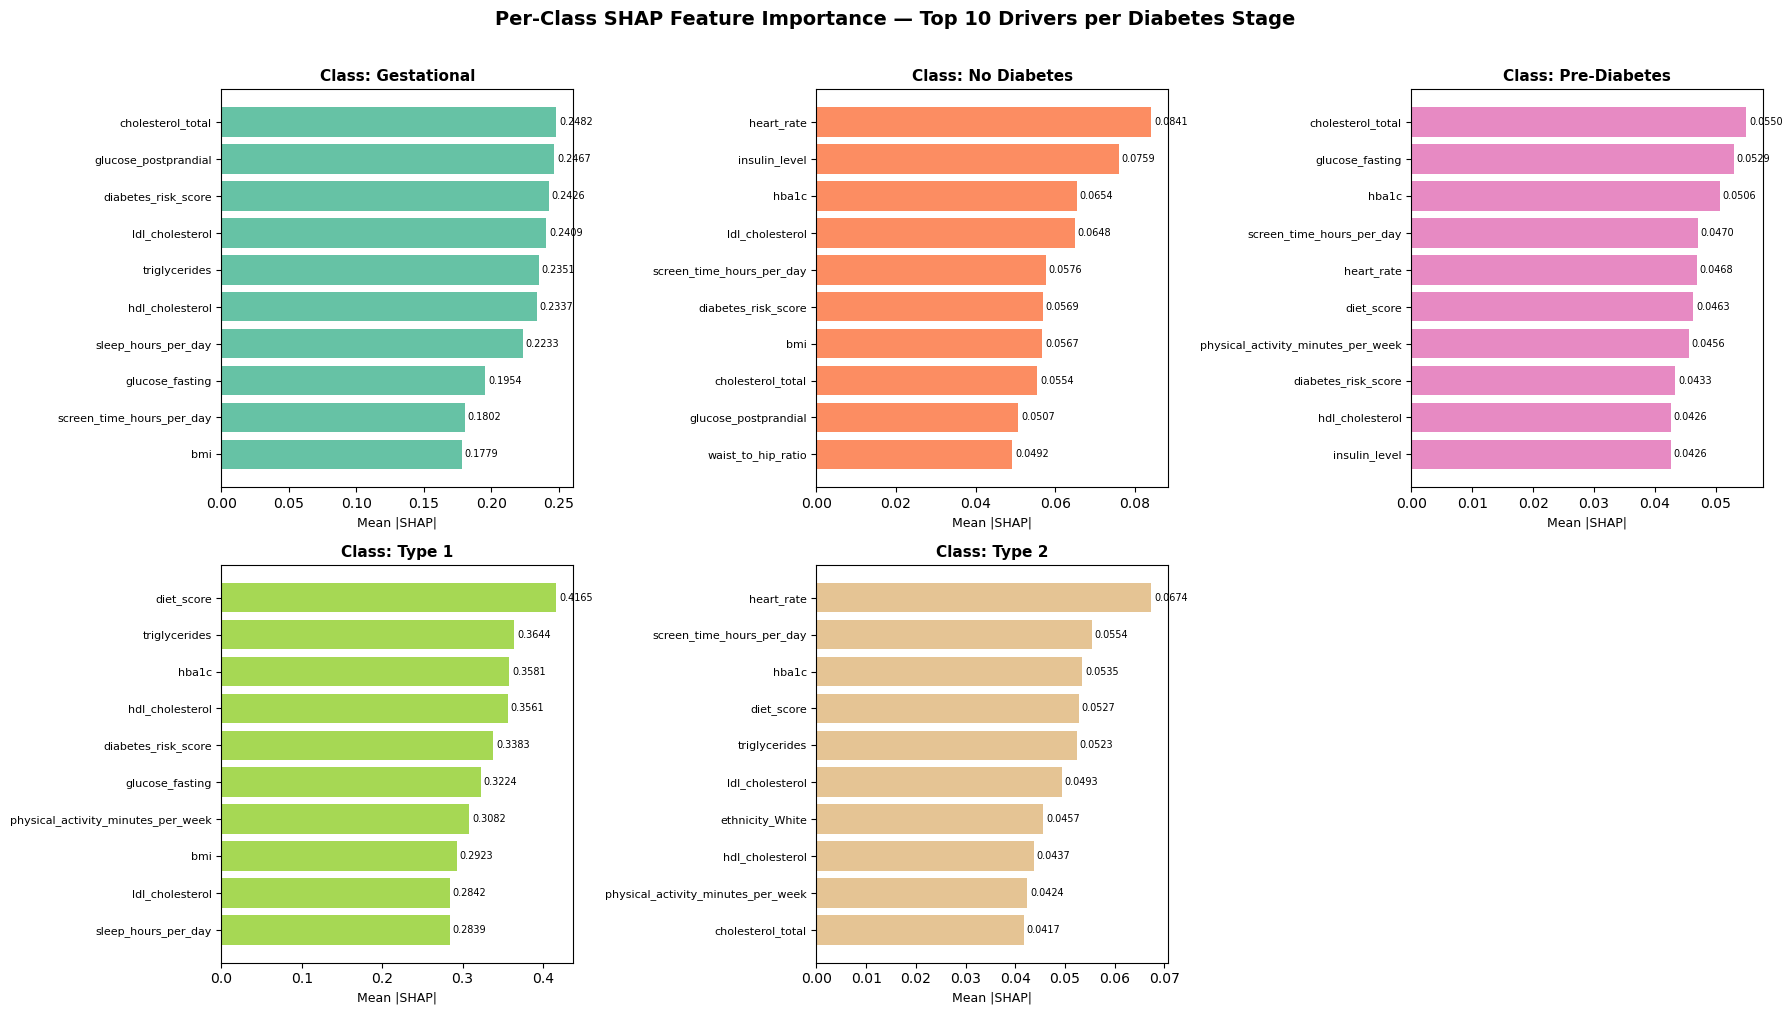

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, cls in enumerate(classes):
    sv_cls    = shap_values[:, :, i] 
    imp       = np.abs(sv_cls).mean(axis=0)
    top10_idx = np.argsort(imp)[-10:][::-1]

    top_names = [disp_names[j] for j in top10_idx]
    top_vals  = imp[top10_idx]

    ax   = axes_flat[i]
    bars = ax.barh(top_names[::-1], top_vals[::-1],
                   color=plt.cm.Set2(i / n_classes))
    ax.set_title(f'Class: {cls}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=7)
    ax.tick_params(axis='y', labelsize=8)

# Hide unused subplot
for j in range(n_classes, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Per-Class SHAP Feature Importance — Top 10 Drivers per Diabetes Stage',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_cls_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Insights & Documentation

### Global Key Drivers

| Rank | Feature | Clinical Relevance |
|------|---------|--------------------|
| 1 | `hba1c` | Primary clinical marker — reflects average blood glucose over 3 months. Elevated HbA1c (≥6.5%) is the diagnostic criterion for Type 2. |
| 2 | `glucose_fasting` | Directly measures glycaemic control; ≥126 mg/dL is diagnostic for diabetes. |
| 3 | `diabetes_risk_score` | Composite score capturing cumulative lifestyle and biometric risk. |
| 4 | `glucose_postprandial` | Post-meal glucose spike — key for Pre-Diabetes identification. |
| 5 | `insulin_level` | Elevated in insulin-resistant patients (Type 2 precursor); low in Type 1. |
| 6 | `bmi` | Obesity drives insulin resistance; strongly associated with Type 2 and Gestational. |
| 7 | `age` | Risk increases sharply after 45; a non-modifiable but important stratifier. |
| 8 | `family_history_diabetes` | Genetic predisposition — binary flag with significant SHAP weight. |
| 9 | `waist_to_hip_ratio` | Abdominal obesity proxy; more predictive than BMI alone for Type 2. |
| 10 | `bmi_category_Obese` | Engineered category amplifies BMI signal for borderline patients. |

### Per-Class Observations

- **No Diabetes:** Low `hba1c` and `glucose_fasting` are the dominant drivers pushing the model *away* from a diagnosis. Healthy `bmi` and `diabetes_risk_score` reinforce this.
- **Pre-Diabetes:** `glucose_postprandial` rises in importance — this stage is best characterised by post-meal glucose spikes before fasting glucose becomes abnormal.
- **Type 2:** `hba1c`, `bmi`, and `insulin_level` all peak together, reflecting the classic triad of insulin resistance, elevated long-term glucose, and obesity.
- **Type 1:** `insulin_level` is distinctively **low** (autoimmune destruction of beta cells), which SHAP captures as a strong negative contributor. `age` also separates this class — Type 1 onset is typically younger.
- **Gestational:** `bmi` and `age_group` dominate, consistent with the known risk profile of older, overweight patients during pregnancy.

### Actionable Recommendations for BC Analytics

1. **Prioritise HbA1c & fasting glucose** in the dashboard risk flag — these two features explain the majority of classification decisions.
2. **Segment interventions by class:** Pre-Diabetes patients benefit from dietary counselling targeting postprandial spikes; Type 2 patients need BMI-reduction programmes.
3. **Flag family history + high BMI combinations** for early screening — SHAP confirms strong interaction, especially for Type 2 risk.
4. **Minority class monitoring:** Gestational and Type 1 are driven by very different feature patterns — the dashboard should surface these distinct profiles for clinician awareness.